# Isotropic elastic wave propagator for the Spyro-SPECFEM2D comparison


This notebook adapts `spyro/notebook_tutorials/elastic_forward.ipynb` to the 2D elastic configuration used in this repository to compare Spyro against SPECFEM2D.


The goal is to reproduce in Spyro the same setup used in the 2D comparison scripts: a fourth-order quadrilateral elastic run on a `3.0 x 3.0` domain, with reflective/non-periodic boundaries, a source at `(-1.1, 1.5)` in Spyro's `(z, x)` convention, 300 receivers from `(z=-1.9, x=1.2)` to `(z=-1.9, x=1.8)`, `dt = 0.001`, `final_time = 1.5`, `rho = 0.1`, `vp = 1.5`, and `vs = 1.0`.


First, the notebook environment is configured and the required modules are imported.


If `spyro` is not installed in the current Python environment, the next code cell tries to load a sibling checkout from `../spyro`, which matches the directory layout used by this comparison repository.


In [30]:
%matplotlib inline
from pathlib import Path
import sys

import numpy as np

cwd = Path.cwd().resolve()
project_root = next(
    (path for path in [cwd, *cwd.parents] if (path / "scripts").exists() and (path / "results").exists()),
    cwd,
)
notebook_dir = project_root / "notebooks"
spyro_repo = project_root.parent / "spyro"
if spyro_repo.exists() and str(spyro_repo) not in sys.path:
    sys.path.insert(0, str(spyro_repo))

import spyro

print(f"Project root: {project_root}")
print(f"Notebook dir: {notebook_dir}")
print(f"Spyro source: {spyro_repo if spyro_repo.exists() else 'installed package'}")


Project root: /Users/ddolci/dev_code/specfem_spyro_elastic_comparison
Notebook dir: /Users/ddolci/dev_code/specfem_spyro_elastic_comparison/notebooks
Spyro source: /Users/ddolci/dev_code/spyro


Then, the commands that are the same as in the elastic tutorial are run, but now with the exact numerical configuration used for the 2D Spyro-SPECFEM2D comparison.


In [31]:
source_z = -1.1
receiver_z = -1.9
edge_length = 0.02
receiver_locations = spyro.create_transect((receiver_z, 1.2), (receiver_z, 1.8), 300)

dictionary = {
    "options": {
        "cell_type": "Q",
        "variant": "lumped",
        "degree": 4,
        "dimension": 2,
    },
    "parallelism": {
        "type": "automatic",
    },
    "mesh": {
        "length_z": 3.0,
        "length_x": 3.0,
        "mesh_file": None,
        "mesh_type": "firedrake_mesh",
    },
    "acquisition": {
        "source_type": "ricker",
        "source_locations": [(source_z, 1.5)],
        "frequency": 5.0,
        "delay": 0.2,
        "delay_type": "time",
        "receiver_locations": receiver_locations,
        "amplitude": np.array([0.0, 1.0]),
    },
    "time_axis": {
        "initial_time": 0.0,
        "final_time": 1.5,
        "dt": 0.001,
        "output_frequency": 100,
        "gradient_sampling_frequency": 1,
    },
    "visualization": {
        "forward_output": False,
        "fwi_velocity_model_output": False,
        "gradient_output": False,
        "adjoint_output": False,
        "debug_output": False,
    },
}


The isotropic elastic wave propagator requires three material parameters: the density ($\rho$) and two parameters for the constitutive behavior. There are multiple equivalent parameter pairs for isotropic linear elasticity. In this notebook, we follow the same `vp`/`vs` choice used in the comparison scripts, with the relation

$$c_p = \sqrt{\frac{\lambda + 2\mu}{\rho}} \qquad\text{and}\qquad c_s = \sqrt{\frac{\mu}{\rho}}$$

so that the Spyro setup stays aligned with the SPECFEM2D comparison case.


In [32]:
dictionary["synthetic_data"] = {
    "type": "object",
    "density": 0.1,
    "p_wave_velocity": 1.5,
    "s_wave_velocity": 1.0,
    "real_velocity_file": None,
}


The isotropic elastic solver in Spyro uses a pure displacement formulation, so the source is a vector body force. For the 2D comparison we use the same vertical point-force orientation adopted in `scripts/run_spyro_elastic_forward.py`.


In [33]:
dictionary["acquisition"]["amplitude"] = np.array([0.0, 1.0])


The class that implements the isotropic elastic wave propagator is `IsotropicWave`. First, we create an instance of this class.


In [34]:
wave = spyro.IsotropicWave(dictionary)


Parallelism type: automatic


/Users/ddolci/dev_code/spyro/spyro/solvers/wave.py:115: UserWarning: No mesh file, Firedrake mesh will be automatically generated.
  warnings.warn(


We set the mesh parameters to define the non-periodic mesh used in the comparison. This is the main change relative to the original tutorial notebook, which used a periodic mesh.

In [35]:
wave.set_mesh(input_mesh_parameters={"edge_length": edge_length, "periodic": False})


Creating firedrake_mesh type mesh.


/Users/ddolci/dev_code/firedrake/firedrake/__future__.py:6: FutureWarning: The symbolic `interpolate` has been moved into `firedrake`
                  and is now the default method for interpolating in Firedrake. The need to
                  `from firedrake.__future__ import interpolate` is now deprecated.
  warnings.warn("""The symbolic `interpolate` has been moved into `firedrake`
/Users/ddolci/dev_code/firedrake/firedrake/__future__.py:6: FutureWarning: The symbolic `interpolate` has been moved into `firedrake`
                  and is now the default method for interpolating in Firedrake. The need to
                  `from firedrake.__future__ import interpolate` is now deprecated.
  warnings.warn("""The symbolic `interpolate` has been moved into `firedrake`
/Users/ddolci/dev_code/firedrake/firedrake/__future__.py:6: FutureWarning: The symbolic `interpolate` has been moved into `firedrake`
                  and is now the default method for interpolating in Firedrake. The need t

Then, the wave propagation may start.


In [36]:
wave.forward_solve()



Solving Forward Problem


/Users/ddolci/dev_code/venv-firedrake/lib/python3.14/site-packages/ufl/utils/sorting.py:94: UserWarning: Applying str() to a metadata value of type TensorProductQuadratureRule, don't know if this is safe.
  warnings.warn(
/Users/ddolci/dev_code/venv-firedrake/lib/python3.14/site-packages/ufl/utils/sorting.py:94: UserWarning: Applying str() to a metadata value of type TensorProductQuadratureRule, don't know if this is safe.
  warnings.warn(


Simulation time is:        0.0 seconds
Simulation time is:        0.1 seconds
Simulation time is:        0.2 seconds
Simulation time is:        0.3 seconds
Simulation time is:        0.4 seconds
Simulation time is:        0.5 seconds
Simulation time is:        0.6 seconds
Simulation time is:        0.7 seconds
Simulation time is:        0.8 seconds
Simulation time is:        0.9 seconds
Simulation time is:        1.0 seconds
Simulation time is:        1.1 seconds
Simulation time is:        1.2 seconds
Simulation time is:        1.3 seconds
Simulation time is:        1.4 seconds
Simulation time is:        1.5 seconds


The final displacement field may be visualized with the following function.


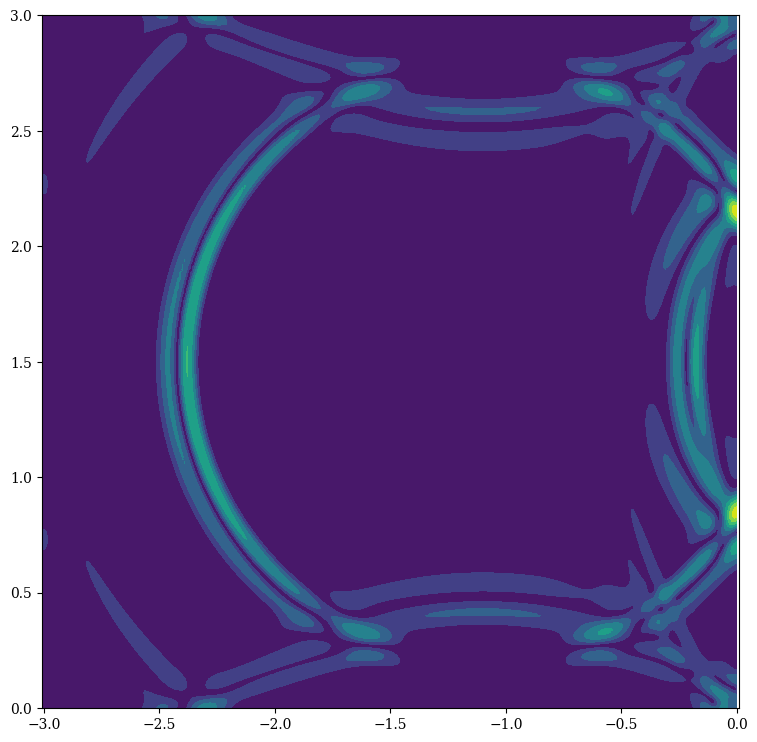

In [37]:
spyro.plots.plot_function(wave.u_n)


The elastic wave equation has one shot record for each direction. The shot record in the $z$ direction is obtained with `out_index=0`; this is the component compared against the vertical SPECFEM2D trace (`BXZ`/`FXZ`, depending on the build).


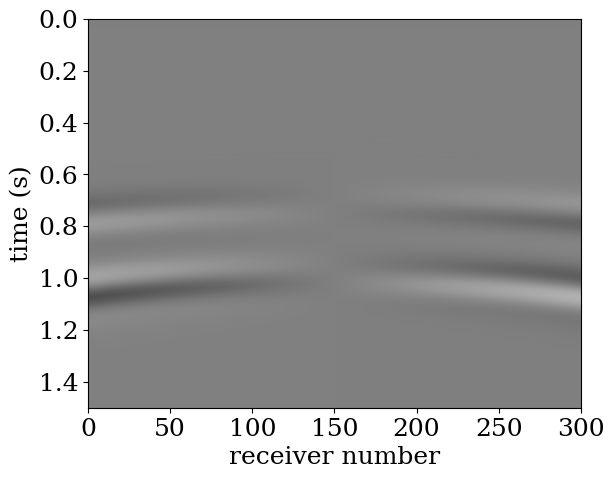

In [38]:
last_displacement = wave.u_n.dat.data[:]
u_max = np.max(np.abs(last_displacement[:, 0]))
spyro.plots.plot_shots(wave, contour_lines=100, vmin=-u_max, vmax=u_max, show=True, out_index=0)


The shot record in the $x$ direction is obtained with `out_index=1`; this is the component compared against the horizontal SPECFEM2D trace (`BXX`/`FXX`).


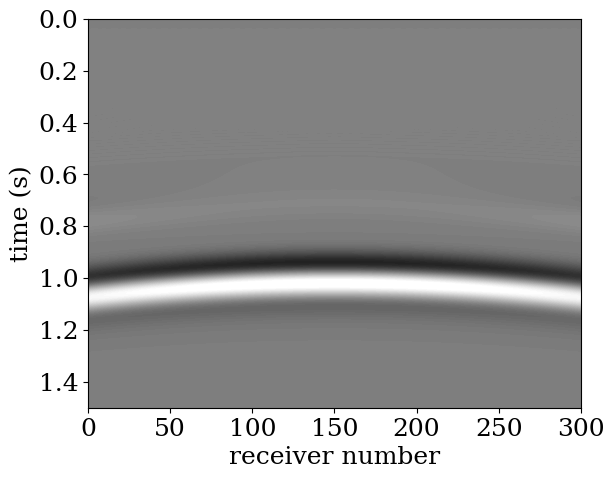

In [39]:
u_max = np.max(np.abs(last_displacement[:, 1]))
spyro.plots.plot_shots(wave, contour_lines=100, vmin=-u_max, vmax=u_max, show=True, out_index=1)


In [40]:
receivers_output = np.asarray(wave.receivers_output)
comparison_summary = {
    "coordinate_order": ["z", "x"],
    "component_order": ["uz", "ux"],
    "edge_length": edge_length,
    "periodic": False,
    "source_location": dictionary["acquisition"]["source_locations"][0],
    "receiver_start": tuple(receiver_locations[0]),
    "receiver_end": tuple(receiver_locations[-1]),
    "num_receivers": len(receiver_locations),
    "dt": dictionary["time_axis"]["dt"],
    "final_time": dictionary["time_axis"]["final_time"],
    "density": dictionary["synthetic_data"]["density"],
    "vp": dictionary["synthetic_data"]["p_wave_velocity"],
    "vs": dictionary["synthetic_data"]["s_wave_velocity"],
    "source_amplitude": dictionary["acquisition"]["amplitude"].tolist(),
    "receivers_output_shape": receivers_output.shape,
}
comparison_summary


{'coordinate_order': ['z', 'x'],
 'component_order': ['uz', 'ux'],
 'edge_length': 0.02,
 'periodic': False,
 'source_location': (-1.1, 1.5),
 'receiver_start': (np.float64(-1.9), np.float64(1.2)),
 'receiver_end': (np.float64(-1.9), np.float64(1.8)),
 'num_receivers': 300,
 'dt': 0.001,
 'final_time': 1.5,
 'density': 0.1,
 'vp': 1.5,
 'vs': 1.0,
 'source_amplitude': [0.0, 1.0],
 'receivers_output_shape': (1501, 300, 2)}

To compare directly against SPECFEM2D, we now export the current Spyro run to `results/spyro`, execute the matching SPECFEM2D case, inspect the assembled SPECFEM parameters and mesh, and then generate the same receiver-comparison figures used in this repository.


In [41]:
import json
import subprocess
from IPython.display import Image, display

spyro_results_dir = project_root / "results" / "spyro"
specfem_results_dir = project_root / "results" / "specfem"
comparison_dir = project_root / "results" / "comparison"

spyro_results_dir.mkdir(parents=True, exist_ok=True)
comparison_dir.mkdir(parents=True, exist_ok=True)

spyro_time = np.arange(receivers_output.shape[0], dtype=float) * dictionary["time_axis"]["dt"]
receiver_locations_array = np.asarray(dictionary["acquisition"]["receiver_locations"], dtype=float)
source_locations_array = np.asarray(dictionary["acquisition"]["source_locations"], dtype=float)
source_wavelet = spyro.full_ricker_wavelet(
    dt=dictionary["time_axis"]["dt"],
    final_time=dictionary["time_axis"]["final_time"],
    frequency=dictionary["acquisition"]["frequency"],
    delay=dictionary["acquisition"]["delay"],
    delay_type=dictionary["acquisition"]["delay_type"],
)
mesh_coordinates = wave.mesh.coordinates.dat.data_ro.copy()
mesh_num_cells = int(wave.mesh.num_cells())
mesh_nx = int(round(dictionary["mesh"]["length_x"] / edge_length))
mesh_nz = int(round(dictionary["mesh"]["length_z"] / edge_length))

np.savez(
    spyro_results_dir / "spyro_receivers.npz",
    time=spyro_time,
    receivers_output=receivers_output,
    receiver_locations=receiver_locations_array,
    source_locations=source_locations_array,
    source_wavelet=source_wavelet,
    mesh_num_cells=mesh_num_cells,
    mesh_coordinates=mesh_coordinates,
)

spyro_metadata = {
    "description": "Notebook-exported reflective Spyro elastic comparison run",
    "coordinate_order": ["z", "x"],
    "component_order": ["uz", "ux"],
    "spectral_degree": int(dictionary["options"]["degree"]),
    "cell_type": "quadrilateral",
    "variant": dictionary["options"]["variant"],
    "periodicity": "none",
    "edge_length": float(edge_length),
    "mesh_num_cells": mesh_num_cells,
    "mesh_shape": {"nx": mesh_nx, "nz": mesh_nz},
    "source_location": source_locations_array[0].tolist(),
    "receiver_start": receiver_locations_array[0].tolist(),
    "receiver_end": receiver_locations_array[-1].tolist(),
    "num_receivers": int(receiver_locations_array.shape[0]),
    "dt": float(dictionary["time_axis"]["dt"]),
    "final_time": float(dictionary["time_axis"]["final_time"]),
    "frequency": float(dictionary["acquisition"]["frequency"]),
    "density": float(dictionary["synthetic_data"]["density"]),
    "vp": float(dictionary["synthetic_data"]["p_wave_velocity"]),
    "vs": float(dictionary["synthetic_data"]["s_wave_velocity"]),
}
(spyro_results_dir / "spyro_metadata.json").write_text(
    json.dumps(spyro_metadata, indent=2),
    encoding="utf-8",
)

print(f"Saved Spyro notebook outputs to {spyro_results_dir}")


Saved Spyro notebook outputs to /Users/ddolci/dev_code/specfem_spyro_elastic_comparison/results/spyro


We now execute the matching SPECFEM2D case by calling `run_specfem2d.sh`, which lives in the same `notebooks/` directory as this notebook. That script keeps the notebook entrypoint local while still using the repository SPECFEM2D workflow and local `third_party/` installation.


In [42]:
specfem_cmd = [
    "bash",
    str(notebook_dir / "run_specfem2d.sh"),
    "--edge-length",
    str(edge_length),
    "--source-z",
    str(source_z),
    "--receiver-z",
    str(receiver_z),
    "--results-dir",
    str(specfem_results_dir),
    "--log-dir",
    str(project_root / "logs"),
]
print("Running:", " ".join(specfem_cmd))
subprocess.run(specfem_cmd, cwd=notebook_dir, check=True)


Running: bash /Users/ddolci/dev_code/specfem_spyro_elastic_comparison/notebooks/run_specfem2d.sh --edge-length 0.02 --source-z -1.1 --receiver-z -1.9 --results-dir /Users/ddolci/dev_code/specfem_spyro_elastic_comparison/results/specfem --log-dir /Users/ddolci/dev_code/specfem_spyro_elastic_comparison/logs
SPECFEM2D case files written to /Users/ddolci/dev_code/specfem_spyro_elastic_comparison/specfem_case/DATA

 **********************************************
 *** Specfem 2-D Mesher - serial version    ***
 **********************************************

 Running Git version of the code corresponding to bb9cd02c663a85253be517441f152e7e9f30684c
 dating 2026-01-20 19:11:31 +0100

 Reading the parameter file...

 Title of the simulation: Spyro elastic forward comparison with fully reflective boundaries (h=0.02000)

   using existing STATIONS file: ./DATA/STATIONS
   file name is ./DATA/STATIONS
   found          300  receivers

 Parameter file successfully read 


 Mesh from internal meshin

CompletedProcess(args=['bash', '/Users/ddolci/dev_code/specfem_spyro_elastic_comparison/notebooks/run_specfem2d.sh', '--edge-length', '0.02', '--source-z', '-1.1', '--receiver-z', '-1.9', '--results-dir', '/Users/ddolci/dev_code/specfem_spyro_elastic_comparison/results/specfem', '--log-dir', '/Users/ddolci/dev_code/specfem_spyro_elastic_comparison/logs'], returncode=0)

After the run, we print the key SPECFEM2D parameters and mesh information. This makes it explicit that the SPECFEM case uses the same geometry, acquisition layout, and reflective-boundary configuration as the Spyro case.


With both runs available on disk, we generate and display the same receiver-comparison figures used by the repository comparison script. This final step is launched with the local notebook-side entrypoint `compare_spyro_specfem2d.sh`.


Running: bash /Users/ddolci/dev_code/specfem_spyro_elastic_comparison/notebooks/compare_spyro_specfem2d.sh
Comparison results saved to /Users/ddolci/dev_code/specfem_spyro_elastic_comparison/results/comparison


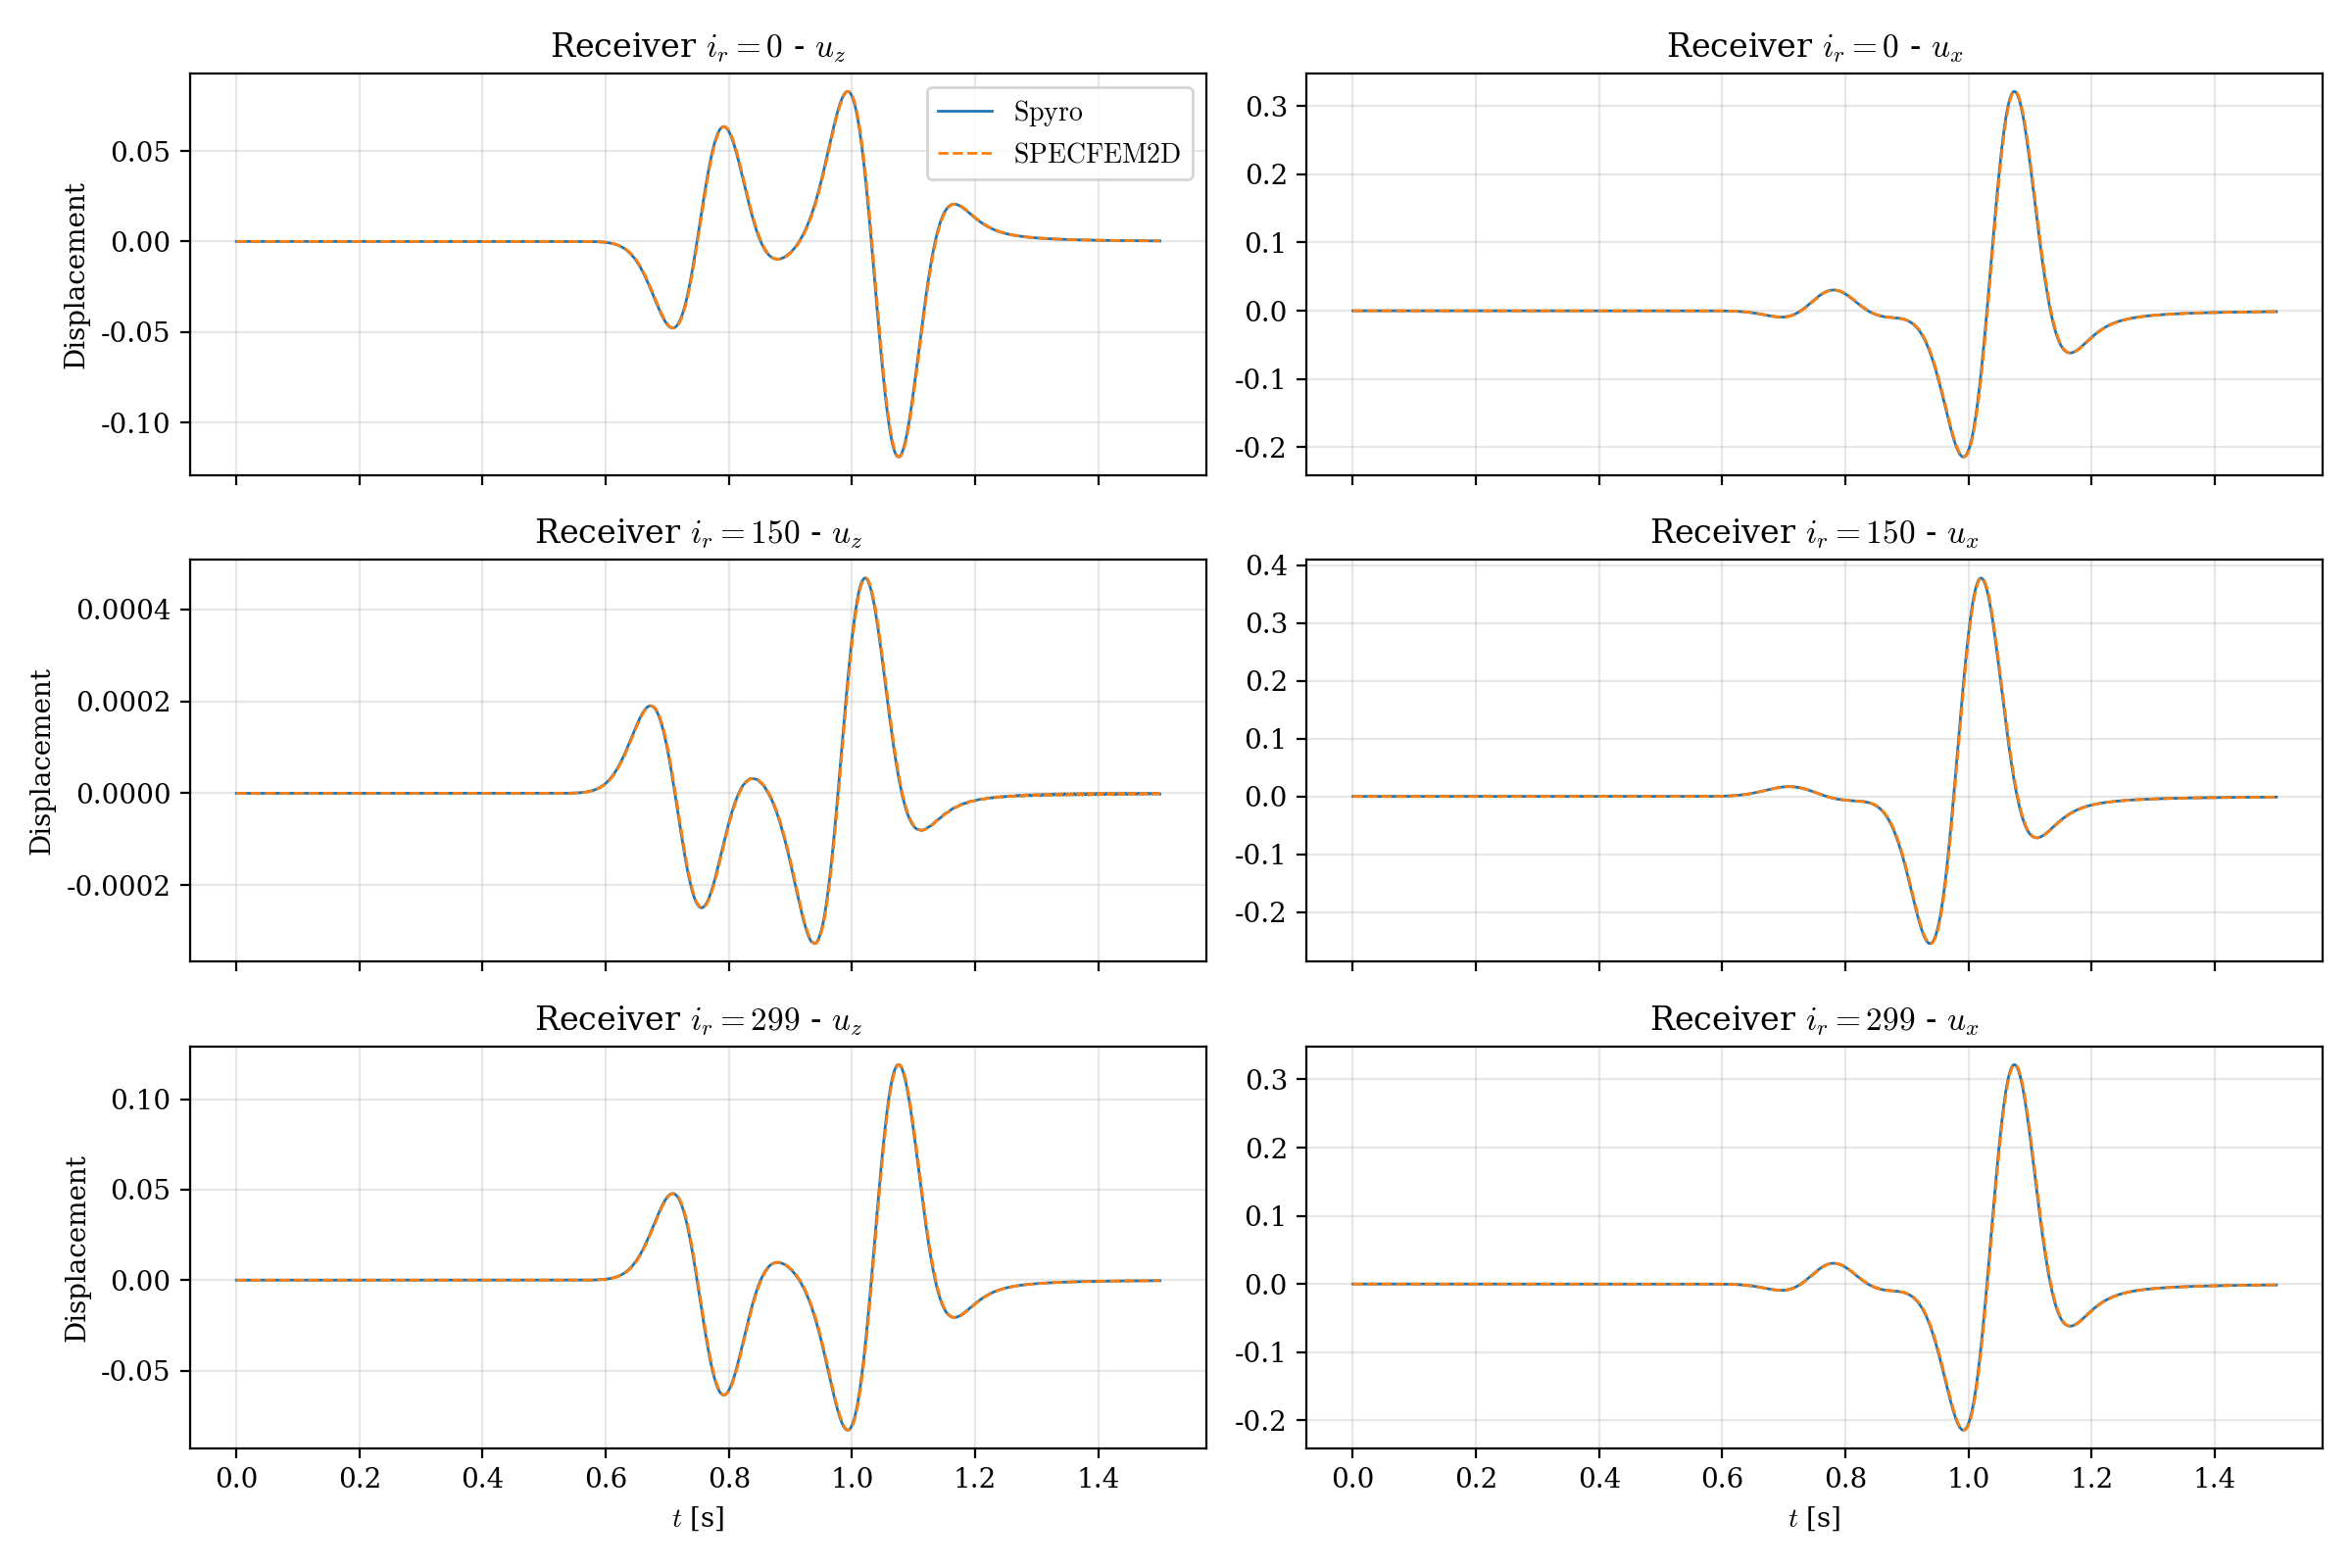

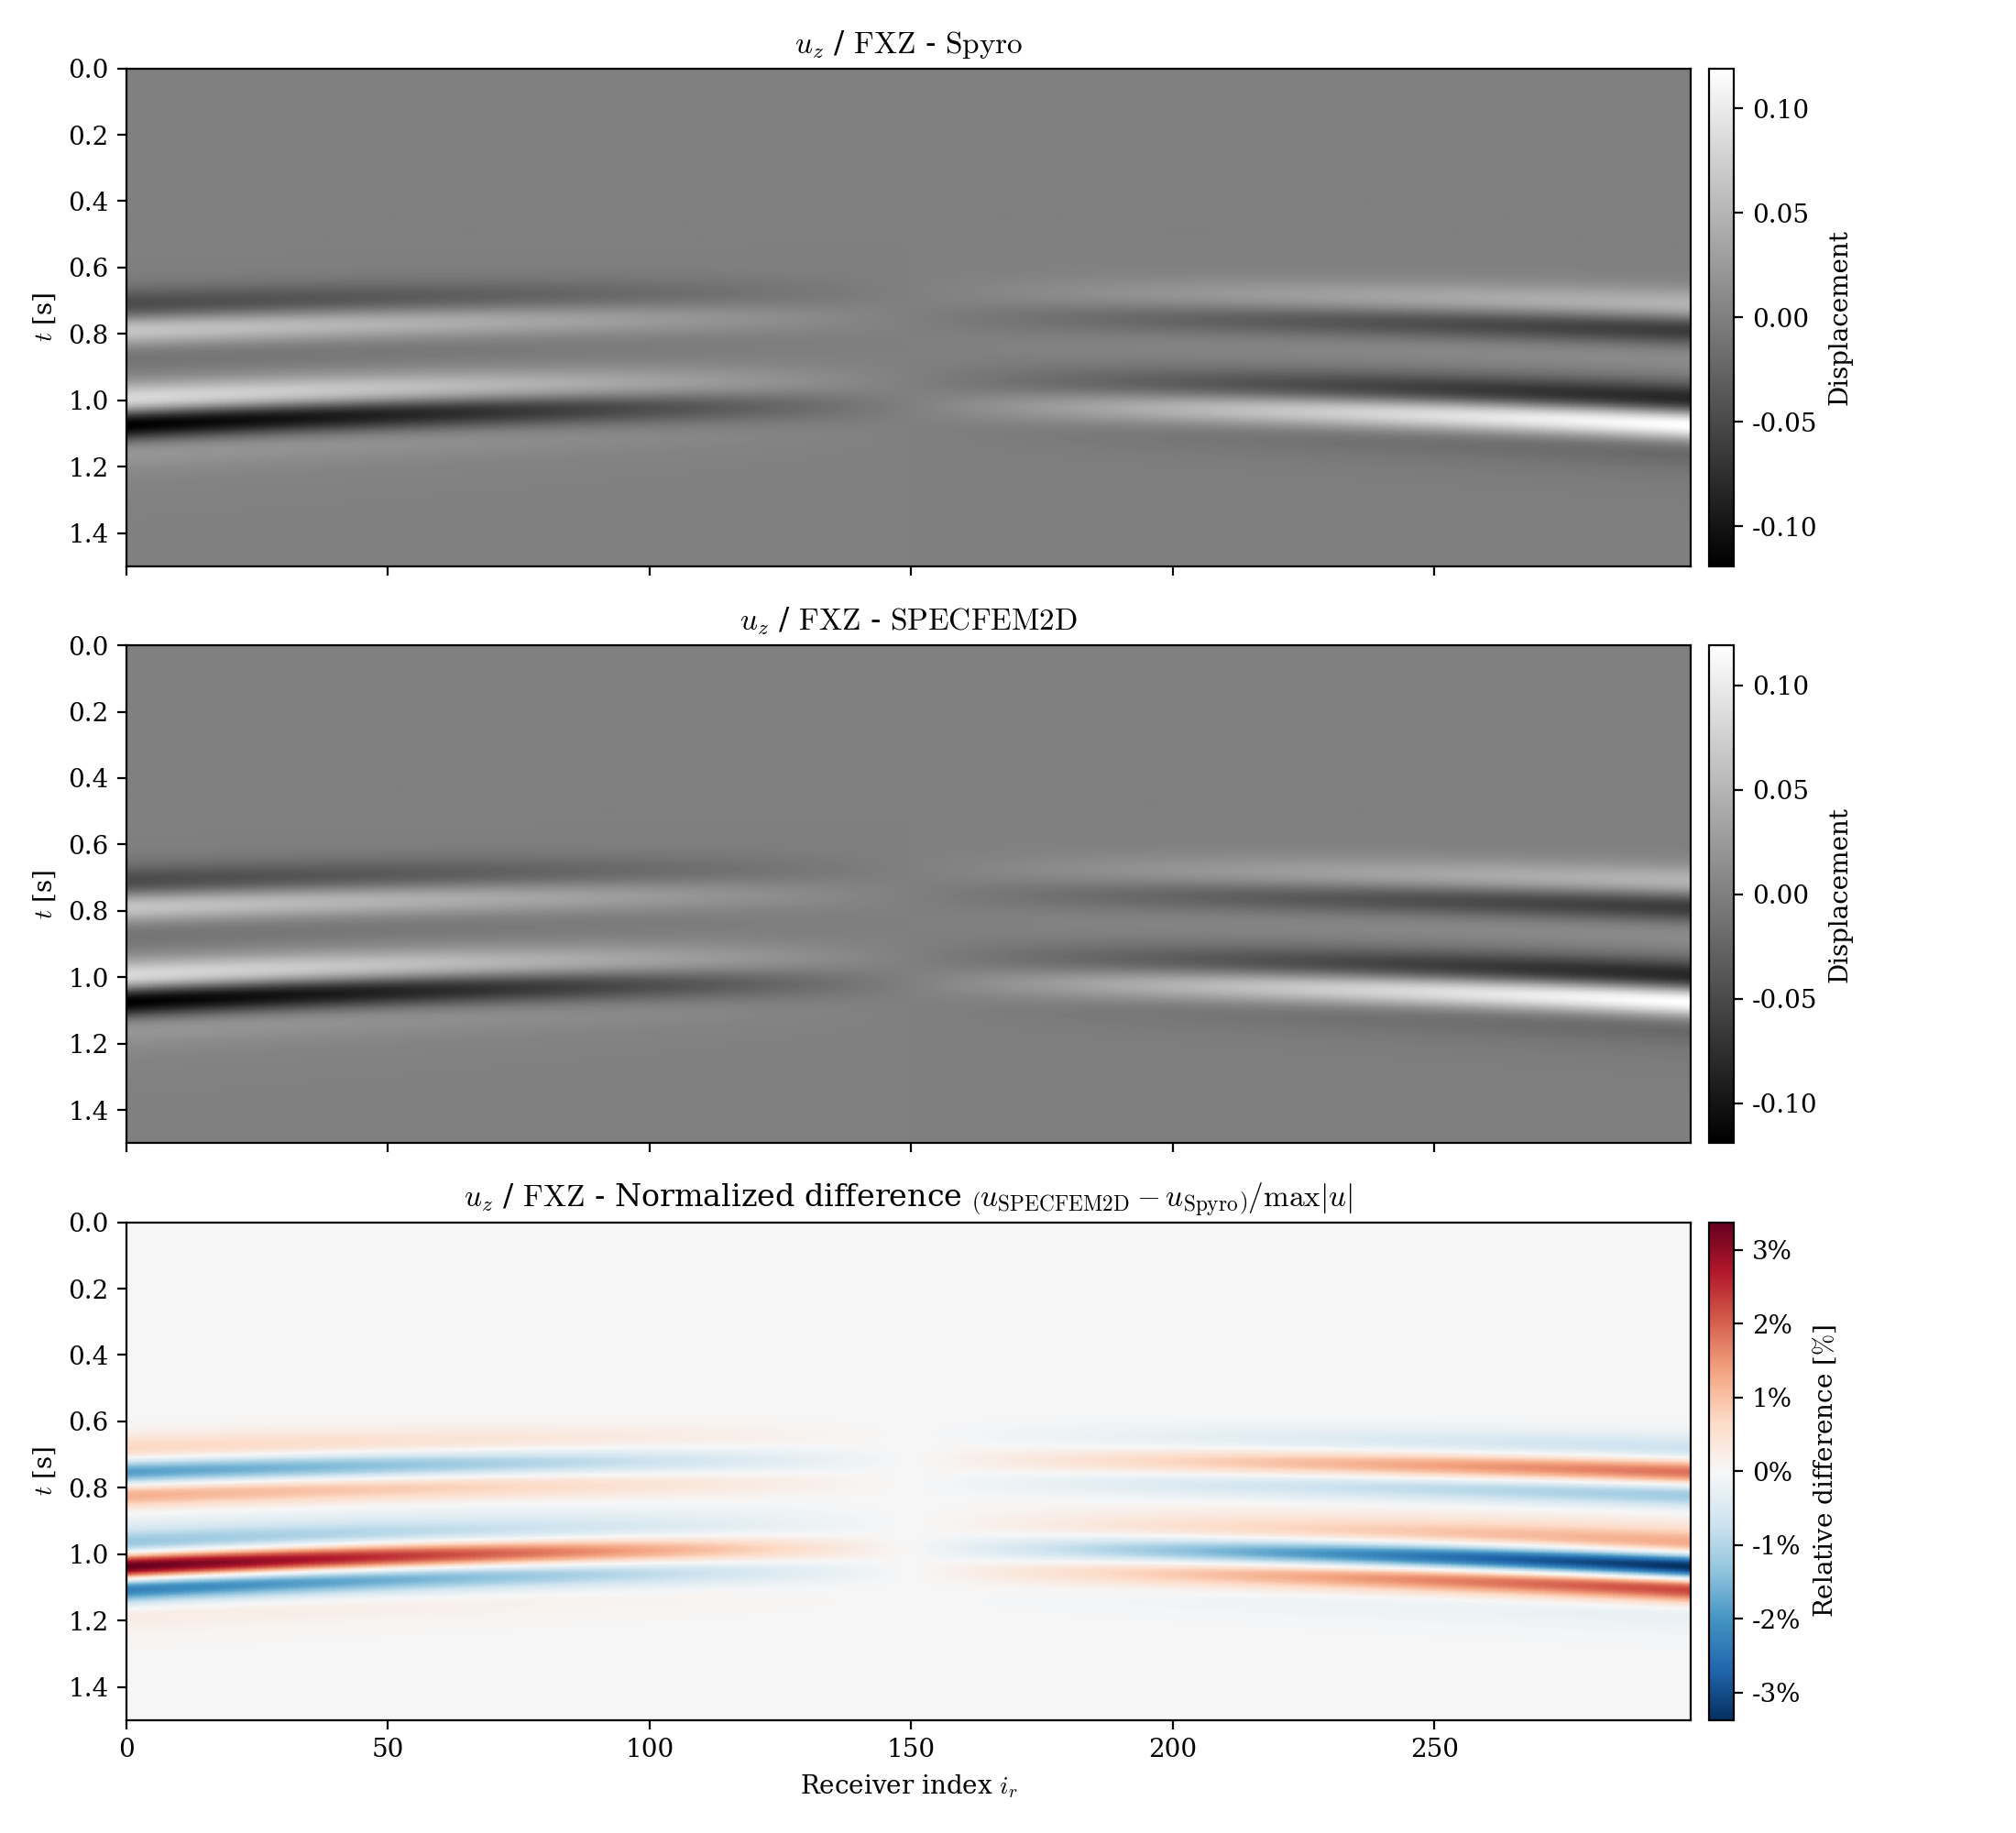

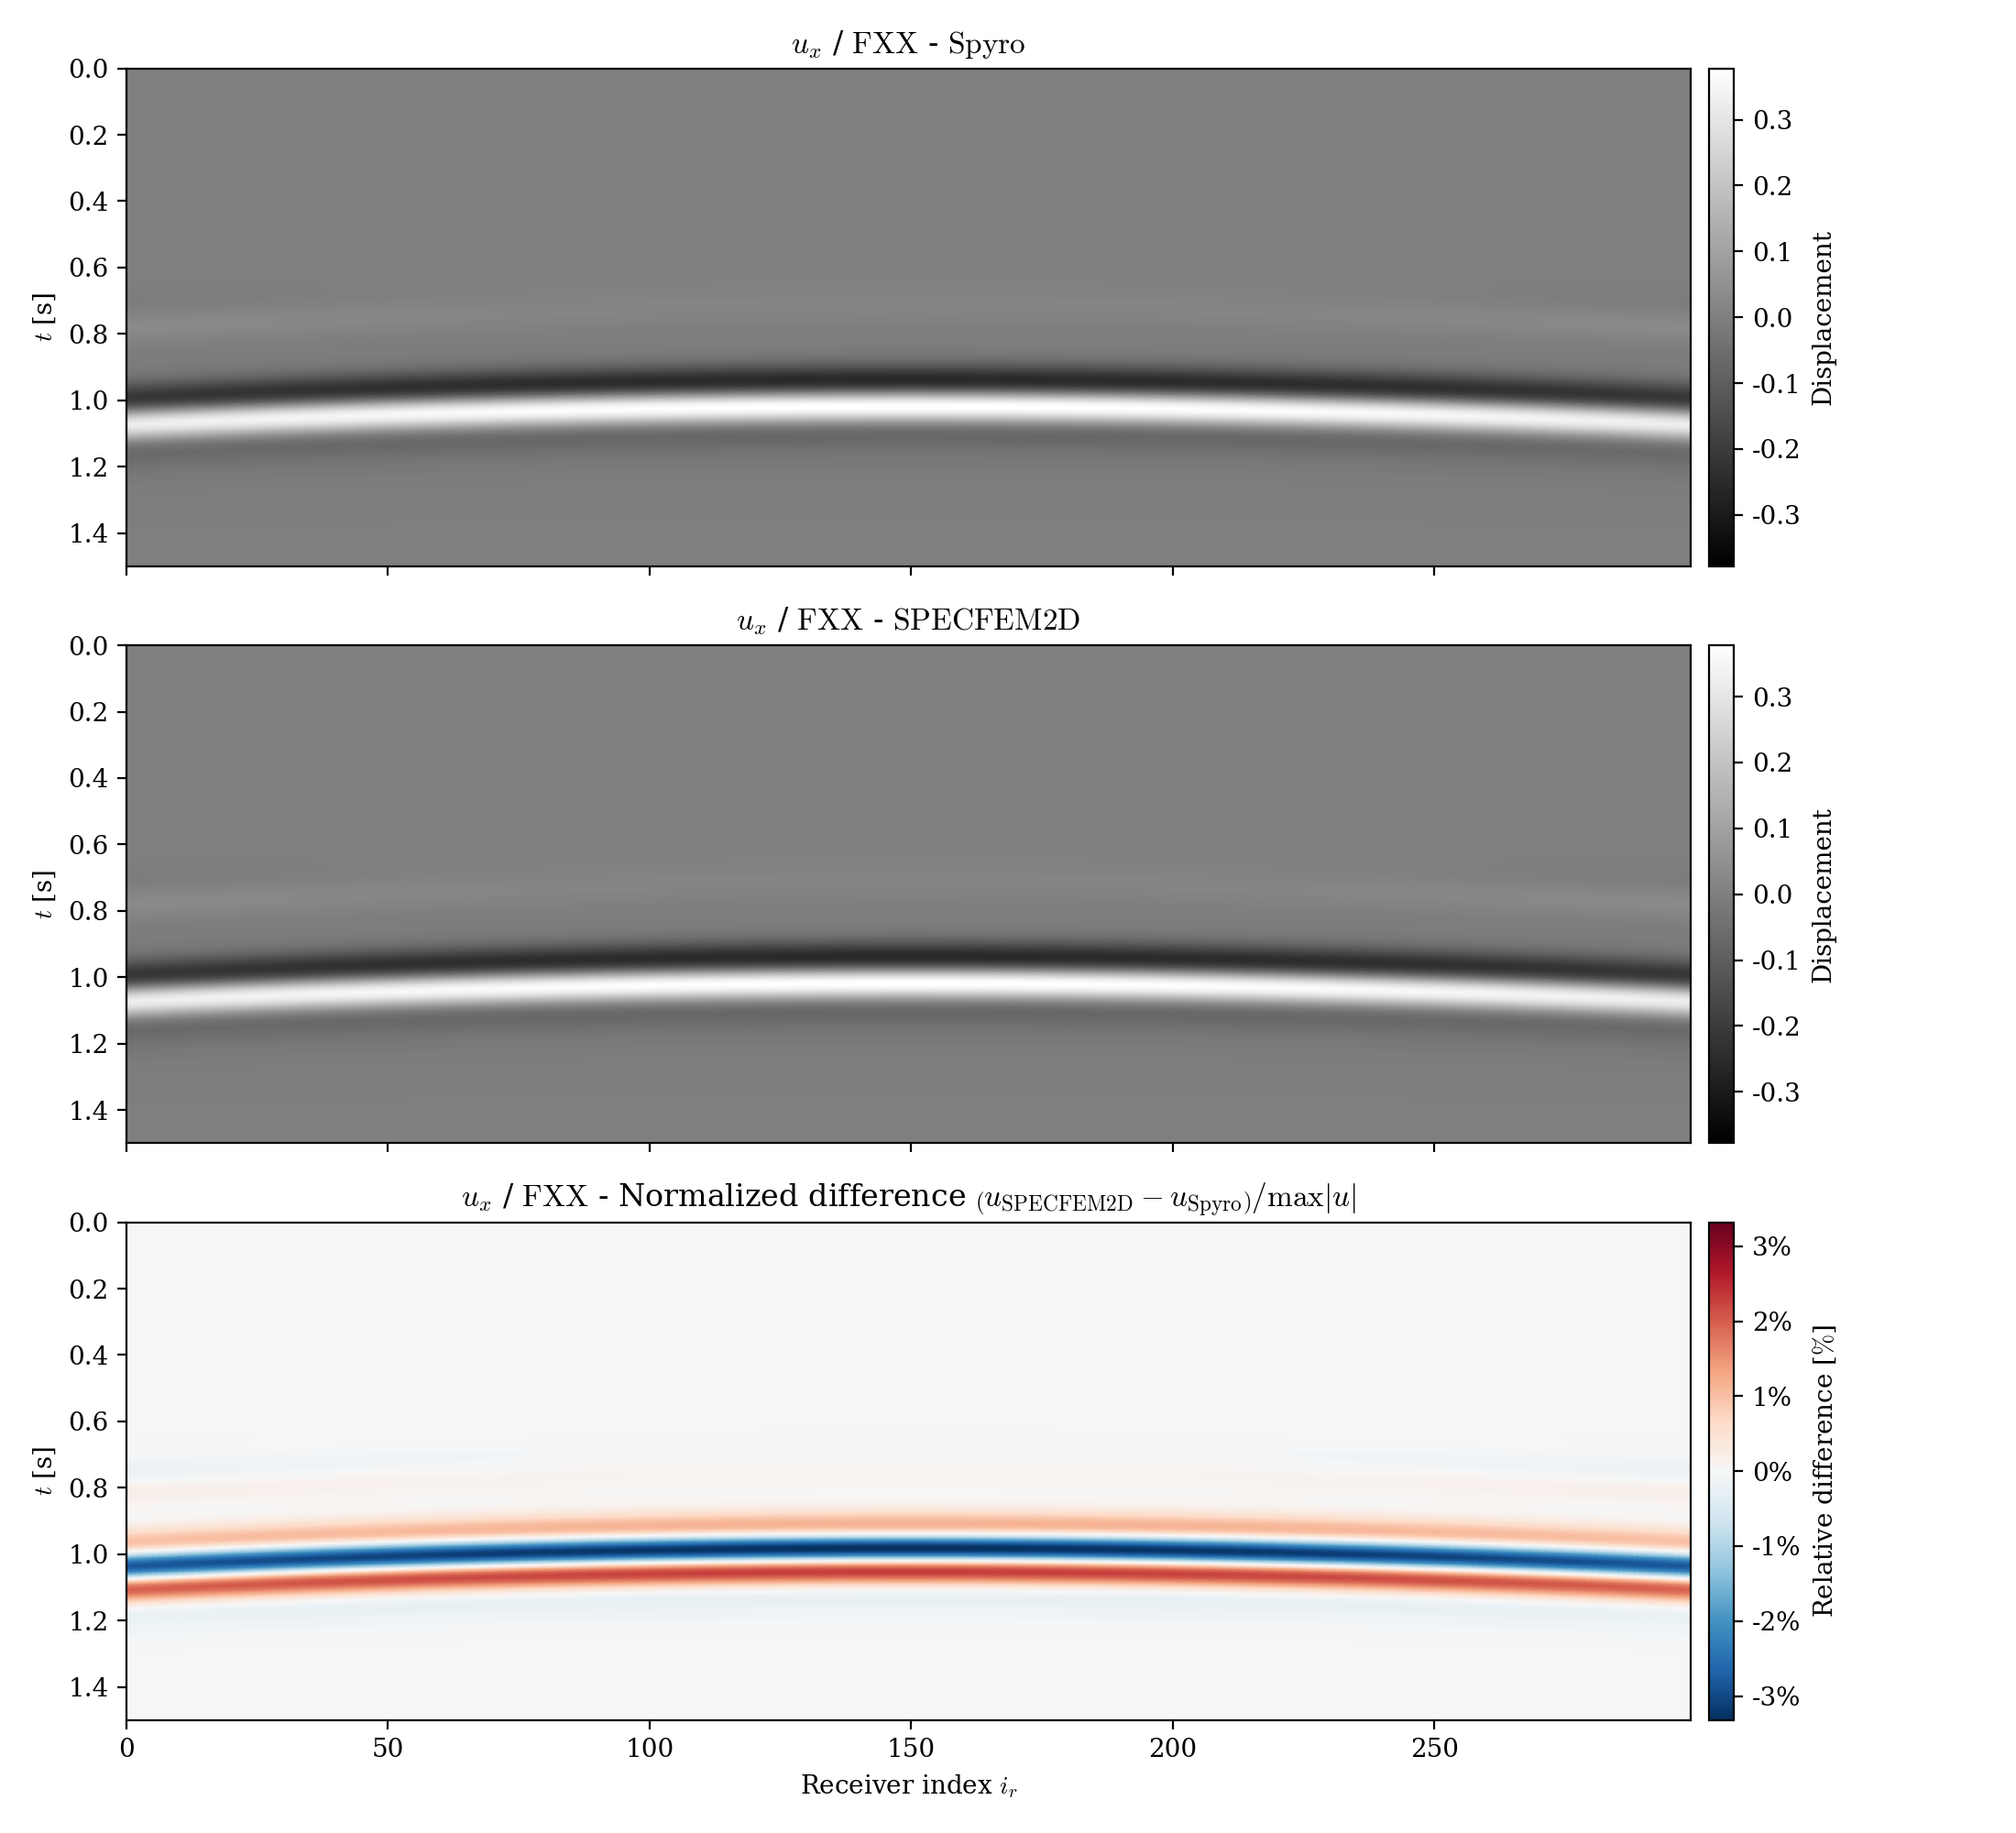

In [43]:
import os

compare_cmd = ["bash", str(notebook_dir / "compare_spyro_specfem2d.sh")]
print("Running:", " ".join(compare_cmd))
compare_env = dict(os.environ)
compare_env["PYTHON"] = sys.executable
subprocess.run(compare_cmd, cwd=notebook_dir, env=compare_env, check=True)

display(Image(filename=str(comparison_dir / "trace_comparison.png")))
display(Image(filename=str(comparison_dir / "uz_bxz_comparison.png")))
display(Image(filename=str(comparison_dir / "ux_bxx_comparison.png")))
